In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

The sample dataset shared consists of typical retail transaction data, which supports a wide range of **descriptive** and **exploratory data analysis** using pandas. Below are categories and examples of analyses possible with such data.

### Common Analysis Types

#### Descriptive Statistics (DONE)
- Calculate **mean**, **median**, for "Customer_Age".
- Find **minimum** and **maximum** values for these columns.
- Compute **standard deviation** and **variance** to understand the spread of the data.

#### Data Visualization (with matplotlib/seaborn) (DONE)
- Plot histograms for customer age
- Create bar charts for sales by country or gender, or time series plots to show trends.

#### Frequency and Distribution (DONE)
- Count frequency of values in categorical columns like "Country", "Customer_Gender", "Product_Category", "Sub_Category".
- Find top-selling products, most common customer demographics, or most frequent purchasing regions.

#### Aggregations & Grouping (DONE)
- Aggregate **total sales** by "Country", "State", "Product_Category", or "Customer_Gender".
- Group data to view average sales, average age, gender distribution within product categories.

#### Derived Metrics
- Calculate **total revenue** per row: $$ Revenue = Order\_Quantity \times Unit\_Price $$.
- Compute **profit margin**: $$ Profit = (Unit\_Price - Unit\_Cost) \times Order\_Quantity $$.

#### Time Series Analysis
- Analyze how sales or orders vary over time using "Date".
- Identify **monthly** or **yearly** sales trends, seasonality in purchases, or age distribution shifts.

#### Segmentation and Filtering
- Segment customers by age groups, gender, country, or product preferences.
- Filter data to identify transactions of high-value products or large order quantities.

### Example Analytical Questions
- What are the top 5 products by total sales and by order quantity?
- Which country or state generates the most revenue?
- Are younger or older customers buying more expensive products?
- Which product categories are most popular among men versus women?

### Advanced Analyses (Optional)
- Customer lifetime value estimates if C_ID is unique and recurring.
- Cohort or retention analysis across different periods.
- Outlier detection in quantities or prices.

These analyses can reveal customer demographics, purchasing patterns, and business performance, and can be implemented using pandas’ aggregation, grouping, and plotting features.

**References**  
 General EDA with pandas  
 Descriptive statistics in pandas  
 GroupBy and summary analytics

In [3]:
df = pd.read_excel("data_sales.xlsx")
print(df.sample(5))

        C_ID       Date  Customer_Age Customer_Gender        Country  \
94742  37013 2016-05-21            41               F      Australia   
93685  55973 2015-12-15            18               M         Canada   
48127  46273 2016-05-27            48               F        Germany   
37109  18463 2013-08-08            30               F  United States   
22553  41615 2016-04-12            44               F         France   

                     State Product_Category       Sub_Category  \
94742      New South Wales      Accessories  Bottles and Cages   
93685     British Columbia      Accessories            Helmets   
48127  Nordrhein-Westfalen      Accessories    Tires and Tubes   
37109           California            Bikes      Touring Bikes   
22553       Hauts de Seine      Accessories    Tires and Tubes   

                       Product  Order_Quantity  Unit_Cost  Unit_Price  
94742    Water Bottle - 30 oz.               8          2           5  
93685  Sport-100 Helmet, B

In [4]:
# I want to see what type of columns and how many records are there.
# I also want to see memory size occupied by df
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113040 entries, 0 to 113039
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   C_ID              113040 non-null  int64         
 1   Date              113040 non-null  datetime64[ns]
 2   Customer_Age      113040 non-null  int64         
 3   Customer_Gender   113040 non-null  object        
 4   Country           113040 non-null  object        
 5   State             113040 non-null  object        
 6   Product_Category  113040 non-null  object        
 7   Sub_Category      113040 non-null  object        
 8   Product           113040 non-null  object        
 9   Order_Quantity    113040 non-null  int64         
 10  Unit_Cost         113040 non-null  int64         
 11  Unit_Price        113040 non-null  int64         
dtypes: datetime64[ns](1), int64(5), object(6)
memory usage: 10.3+ MB
None


#### Descriptive Statistics
- Calculate **mean**, **median**, for "Customer_Age".
- Find **minimum** and **maximum** values for these columns.
- Compute **standard deviation** and **variance** to understand the spread of the data.


In [6]:
# Lets calculate descriptive stats for Customer_Age
print(df[["Customer_Age"]].describe())

        Customer_Age
count  113040.000000
mean       35.920984
std        11.025766
min        17.000000
25%        28.000000
50%        35.000000
75%        43.000000
max        87.000000


#### Data Visualization (with matplotlib/seaborn)
- Plot histograms for customer age
- Create bar charts for sales by country or gender, or time series plots to show trends.


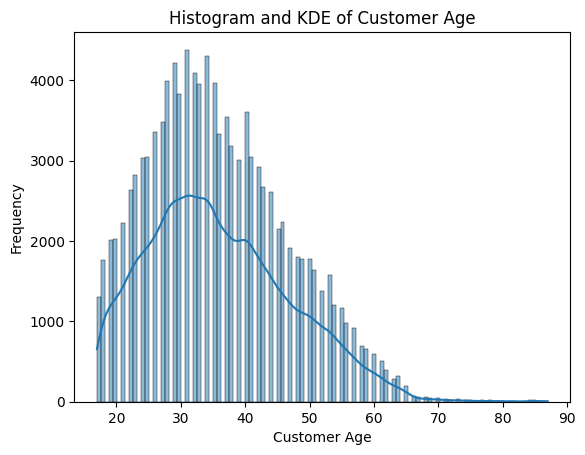

In [8]:
sns.histplot(data=df, x="Customer_Age", kde=True)
plt.xlabel('Customer Age')
plt.ylabel('Frequency')
plt.title('Histogram and KDE of Customer Age')
plt.show()

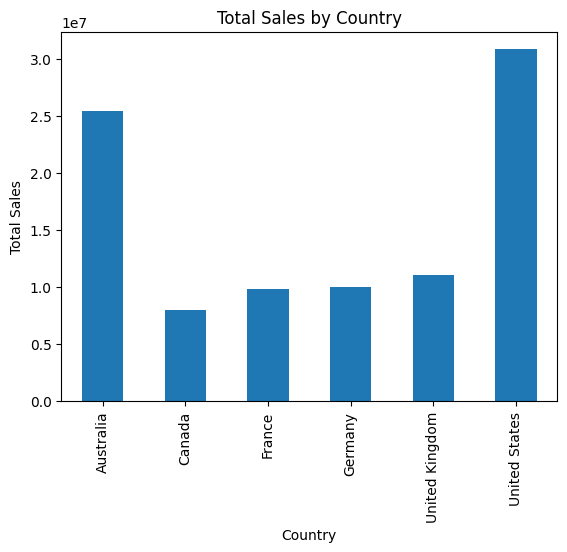

In [9]:
# Create bar charts for sales by country

# Compute total sales per row
df["Sales"] = df["Order_Quantity"] * df["Unit_Price"]

# Group by country and sum sales, then plot
df.groupby("Country")["Sales"].sum().plot(kind="bar")

plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.title("Total Sales by Country")
plt.show()

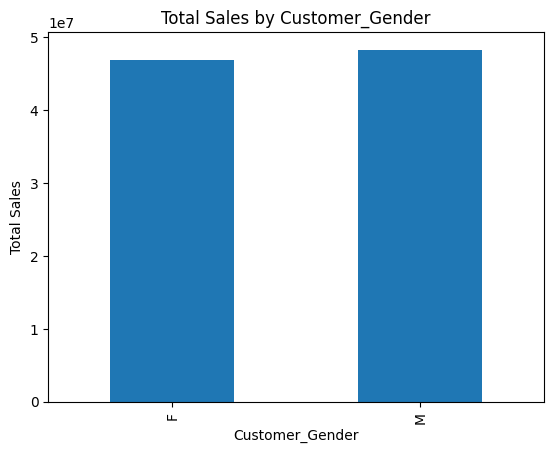

In [10]:
# Create bar charts for sales by Customer_Gender

# Compute total sales per row
df["Sales"] = df["Order_Quantity"] * df["Unit_Price"]

# Group by country and sum sales, then plot
df.groupby("Customer_Gender")["Sales"].sum().plot(kind="bar")

plt.xlabel("Customer_Gender")
plt.ylabel("Total Sales")
plt.title("Total Sales by Customer_Gender")
plt.show()

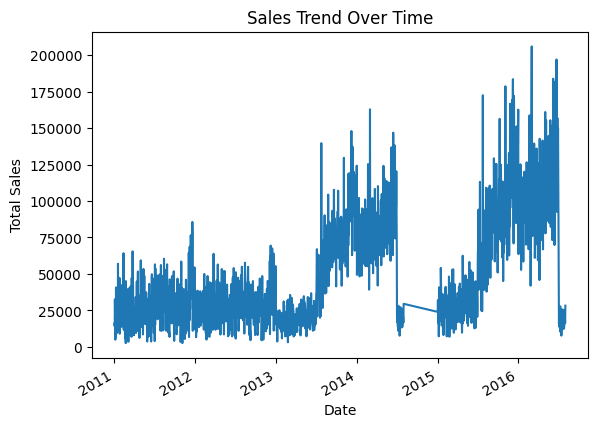

In [11]:
# Group by date (you can resample by month, day, etc.)
sales_trend = df.groupby('Date')['Sales'].sum()

# Plot the time series
sales_trend.plot()
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('Sales Trend Over Time')
plt.show()

#### Frequency and Distribution
- Count frequency of values in categorical columns like "Country", "Customer_Gender", "Product_Category", "Sub_Category". Plot them so they are easy to visualize.
- Find top-selling products, most common customer demographics, or most frequent purchasing regions.


Country
United States     39206
Australia         23937
Canada            14178
United Kingdom    13620
Germany           11101
France            10998
Name: count, dtype: int64


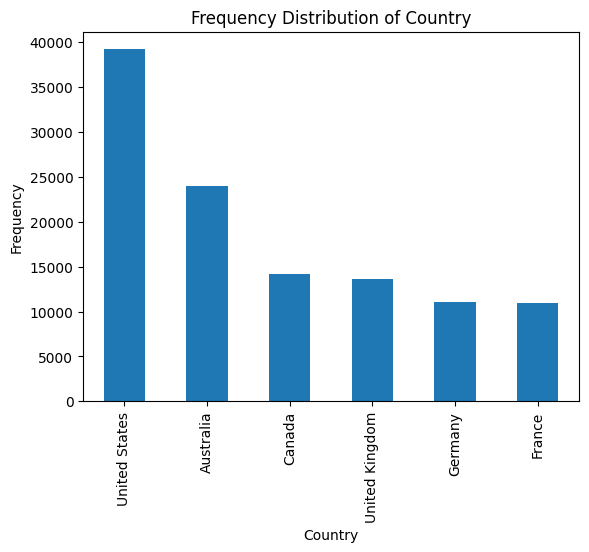


+++++

Customer_Gender
M    58315
F    54725
Name: count, dtype: int64


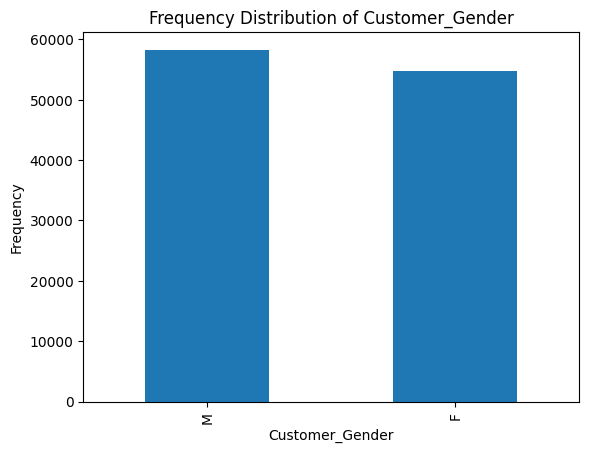


+++++

Product_Category
Accessories    70122
Bikes          25982
Clothing       16936
Name: count, dtype: int64


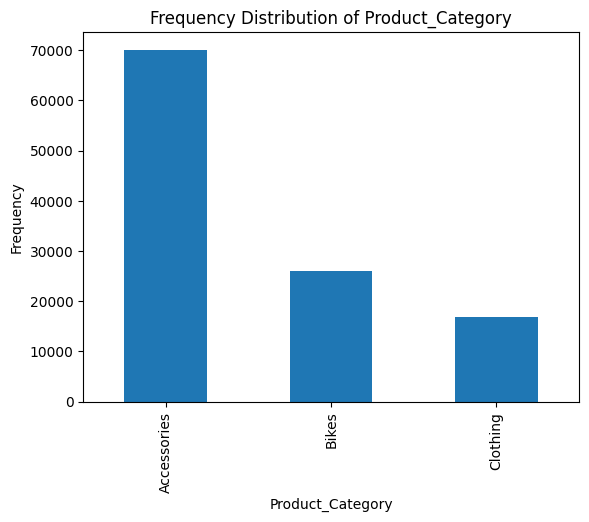


+++++

Sub_Category
Tires and Tubes      33870
Bottles and Cages    15876
Road Bikes           13430
Helmets              12158
Mountain Bikes        8854
Jerseys               6010
Caps                  4358
Fenders               4034
Touring Bikes         3698
Gloves                2686
Cleaners              1802
Shorts                1794
Hydration Packs       1334
Socks                 1122
Vests                  966
Bike Racks             592
Bike Stands            456
Name: count, dtype: int64


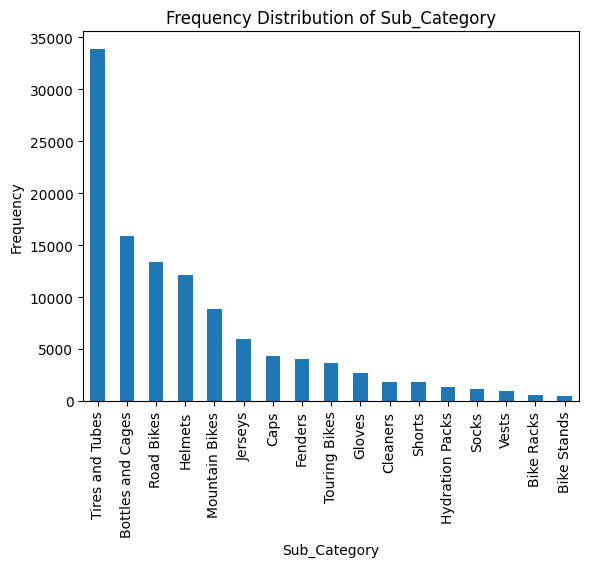


+++++



In [19]:
columns = ["Country", "Customer_Gender", "Product_Category", "Sub_Category"]
for col in columns:
    counts = df[col].value_counts()
    print(counts)
    counts.plot(kind='bar', xlabel=f'{col}', ylabel='Frequency', title=f'Frequency Distribution of {col}')
    plt.show()
    print("\n+++++\n") 

Sub_Category
Tires and Tubes      33870
Bottles and Cages    15876
Helmets              12158
Fenders               4034
Cleaners              1802
Hydration Packs       1334
Bike Racks             592
Bike Stands            456
Name: count, dtype: int64


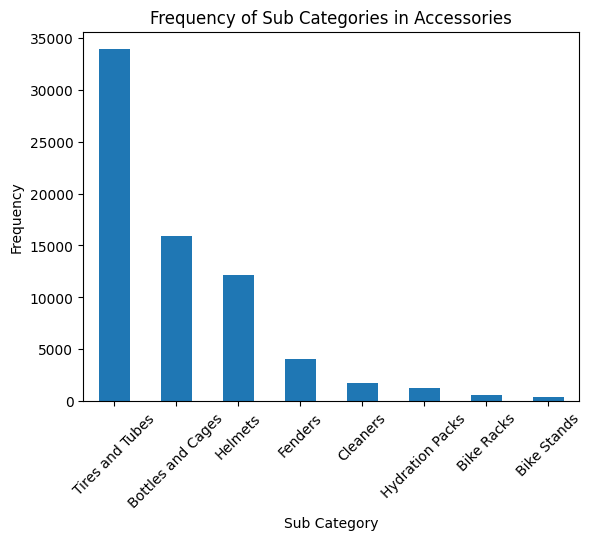

++++

Sub_Category
Road Bikes        13430
Mountain Bikes     8854
Touring Bikes      3698
Name: count, dtype: int64


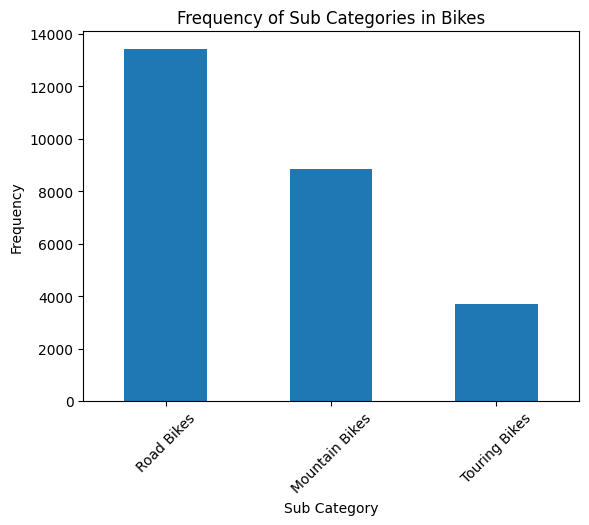

++++

Sub_Category
Jerseys    6010
Caps       4358
Gloves     2686
Shorts     1794
Socks      1122
Vests       966
Name: count, dtype: int64


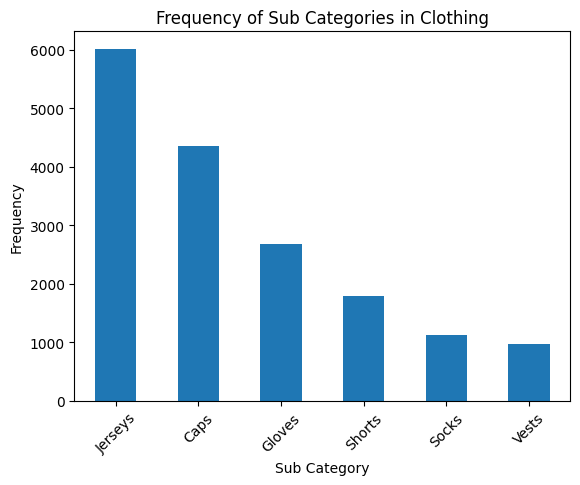

++++



In [23]:
# I want to see the frequency plot of each sub_category within category.

categories = ['Accessories', 'Bikes', 'Clothing']

for cat in categories:
    # Filter for Accessories category
    df_filter = df[df['Product_Category'] == cat]
    
    # Count frequency of sub-categories in Accessories
    sub_cat_counts = df_filter['Sub_Category'].value_counts()
    print(sub_cat_counts)
    
    # Plot bar chart
    sub_cat_counts.plot(kind='bar',
                        xlabel='Sub Category', ylabel='Frequency',
                        title=f'Frequency of Sub Categories in {cat}',
                        rot=45)
    plt.show()
    print("++++\n")


Age group distribution:
 Age_Group
0-17      1306
18-29    34608
30-44    52442
45-59    21854
60+       2830
Name: count, dtype: int64


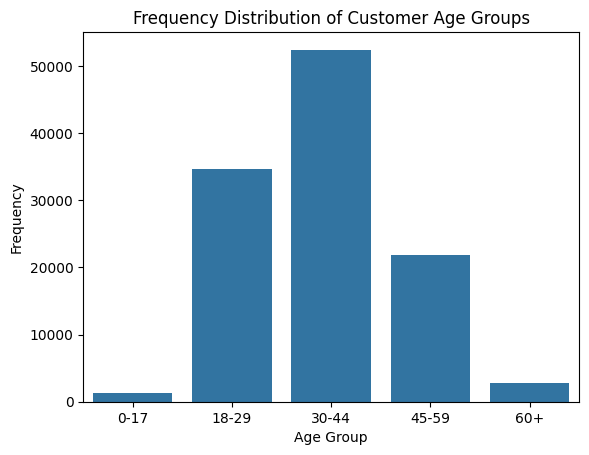

In [26]:
# I want to see the distribution of age groups

# Create age bins for Customer_Age and count frequencies
bins   = [ 0,      18,      30,      45,      60,      100]
labels = ['0-17', '18-29', '30-44', '45-59', '60+']
df['Age_Group'] = pd.cut(df['Customer_Age'], bins=bins, labels=labels, right=False)
age_group_counts = df['Age_Group'].value_counts().sort_index()

print("Age group distribution:\n", age_group_counts)


# Plot frequency of age groups using seaborn
sns.countplot(data=df, x='Age_Group', order=labels)

plt.xlabel('Age Group')
plt.ylabel('Frequency')
plt.title('Frequency Distribution of Customer Age Groups')
plt.show()

#### Aggregations & Grouping
- Aggregate **total sales** by "Country", "State", "Product_Category", or "Customer_Gender".
- Group data to view average unit price, average age, gender distribution within product categories.

In [30]:
# Aggregate total sales by Country
sales_by_country = df.groupby("Country")["Sales"].sum()

# Aggregate total sales by Product_Category
sales_by_category = df.groupby("Product_Category")["Sales"].sum()

# Aggregate total sales by Customer_Gender
sales_by_gender = df.groupby("Customer_Gender")["Sales"].sum()

# Aggregate total sales by multiple columns — Country and Category
sales_by_multiple = df.groupby(["Country", "Product_Category"])["Sales"].sum()

# To view the results
print(sales_by_country,"\n")
print(sales_by_category,"\n")
print(sales_by_gender,"\n")
print("\n\n+++\n")
print(sales_by_multiple)


Country
Australia         25428224
Canada             8014536
France             9847213
Germany            9986573
United Kingdom    11090006
United States     30814774
Name: Sales, dtype: int64 

Product_Category
Accessories    16713878
Bikes          69208196
Clothing        9259252
Name: Sales, dtype: int64 

Customer_Gender
F    46845682
M    48335644
Name: Sales, dtype: int64 



+++

Country         Product_Category
Australia       Accessories          3285425
                Bikes               20231486
                Clothing             1911313
Canada          Accessories          2305298
                Bikes                4317696
                Clothing             1391542
France          Accessories          1627689
                Bikes                7378349
                Clothing              841175
Germany         Accessories          1725143
                Bikes                7544500
                Clothing              716930
United Kingdom  Accessories      

In [33]:
# Group by Product_Category
grouped = df.groupby('Product_Category').agg({
    'Sales': 'mean',          # Average sales
    'Customer_Age': 'mean',   # Average customer age
})

print(grouped)

                        Sales  Customer_Age
Product_Category                           
Accessories        238.354268     36.085651
Bikes             2663.697791     35.348241
Clothing           546.720123     36.117855


In [34]:
# step1: Gender count within each product category
gender_dist = df.groupby(['Product_Category', 'Customer_Gender']).size().unstack(fill_value=0)
print(gender_dist)

Customer_Gender       F      M
Product_Category              
Accessories       33845  36277
Bikes             12852  13130
Clothing           8028   8908


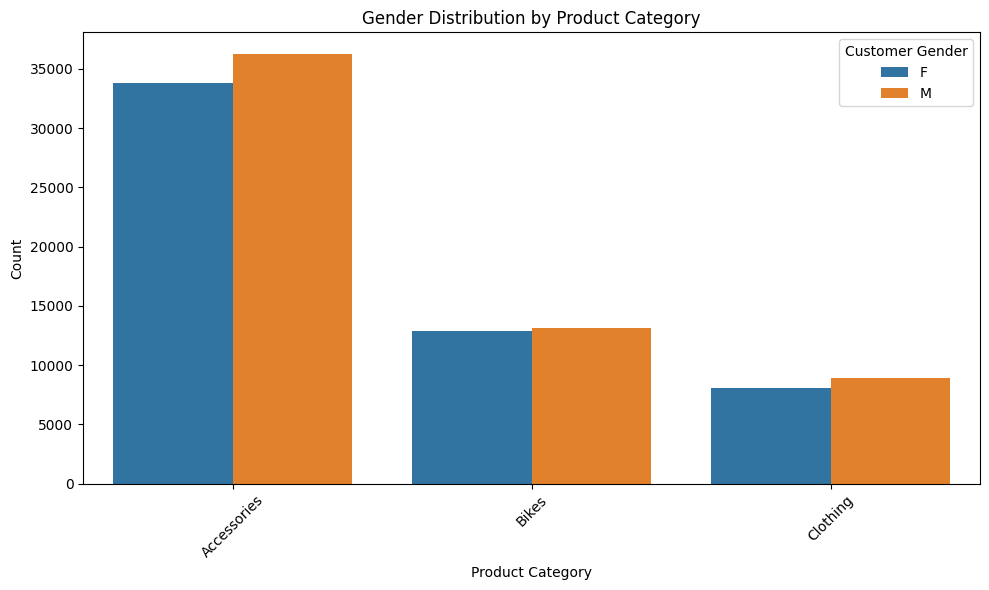

In [35]:
# step2
# Reset index to convert Product_Category into a column
gender_dist_reset = gender_dist.reset_index()

# Convert from wide to long format
gender_long = gender_dist_reset.melt(id_vars='Product_Category', var_name='Customer_Gender', value_name='Count')

# Plot using seaborn
plt.figure(figsize=(10, 6))
sns.barplot(data=gender_long, x='Product_Category', y='Count', hue='Customer_Gender')

plt.title('Gender Distribution by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Customer Gender')
plt.tight_layout()
plt.show()